In [2]:
%load_ext cython

In [6]:
%%cython

# =========================================================================
# PART 1: C LIBRARY IMPORTS AND GLOBAL DEFINITIONS
# =========================================================================

from libc.stdlib cimport malloc, free, srand, rand
from libc.string cimport memset
from libc.math cimport exp

# Import Python libraries needed for the LLM part
import time
import json
import ollama
import numpy as np
import hashlib
from collections import defaultdict
import random
import threading
import queue
import gc

# Constants for the enhanced algorithm
cdef int NBITEMS = 250
cdef int ni = 250
cdef int L = 5  # This will be adjusted by the LLM
cdef double LARGE = 10e50
cdef float smallValue = 0.0000001
cdef double kappa = 0.05  # This will be adjusted by the LLM
cdef int alpha = 5  # Reduced from 10 to 5 for memory
cdef int paretoIni = 28000

# Enhanced data structures inspired by research papers
cdef struct ind:
    int nombr_nonpris
    int nombr
    int rank
    float fitnessbest
    float fitness
    int explored
    double *f
    double *capa
    double *v
    int *d
    int *Items
    int age
    int improvement_count
    int llm_enhanced
    int last_improvement_iteration
    int generation
    int parent1_id
    int parent2_id
    float diversity_score

cdef struct pop:
    int size
    int maxsize
    ind **ind_array

# Global variables for the problem instance
cdef int nf = 2
cdef double *capacities = NULL
cdef int **weights = NULL
cdef int **profits = NULL
cdef double *vector_weight = NULL
cdef double max_bound = 0.0
cdef double **OBJ_Weights = NULL
cdef int nombreLIGNE = 0
cdef int nextLn = 0
cdef int inv = 0
cdef int OBJ_Weights_lines = 0

# =========================================================================
# PART 2: CORE CYTHON HELPER FUNCTIONS
# =========================================================================

def seed(int x):
    srand(x)

cdef int irand(int range_val):
    return rand() % range_val

cdef void *chk_malloc(size_t size):
    cdef void *return_value = malloc(size)
    if return_value == NULL:
        raise MemoryError("Out of memory.")
    memset(return_value, 0, size)
    return return_value

cdef pop *create_pop(int maxsize, int nf):
    cdef int i
    cdef pop *pp = <pop *>chk_malloc(sizeof(pop))
    pp.size = 0
    pp.maxsize = maxsize
    pp.ind_array = <ind **>chk_malloc(maxsize * sizeof(void*))
    for i in range(maxsize):
        pp.ind_array[i] = NULL
    return pp

cdef ind *create_ind(int nf):
    cdef int i
    cdef ind *p_ind = <ind *>chk_malloc(sizeof(ind))
    p_ind.nombr_nonpris = 0
    p_ind.nombr = 0
    p_ind.rank = 0
    p_ind.fitnessbest = -1.0
    p_ind.fitness = -1.0
    p_ind.explored = 0
    p_ind.age = 0
    p_ind.improvement_count = 0
    p_ind.llm_enhanced = 0
    p_ind.last_improvement_iteration = 0
    p_ind.generation = 0
    p_ind.parent1_id = -1
    p_ind.parent2_id = -1
    p_ind.diversity_score = 0.0
    p_ind.f = <double *>chk_malloc(nf * sizeof(double))
    p_ind.capa = <double *>chk_malloc(nf * sizeof(double))
    p_ind.v = <double *>chk_malloc(nf * sizeof(double))
    p_ind.d = <int *>chk_malloc(ni * sizeof(int))
    p_ind.Items = <int *>chk_malloc(ni * sizeof(int))
    for i in range(ni):
        p_ind.Items[i] = 0
        p_ind.d[i] = 0
    for i in range(nf):
        p_ind.f[i] = 0.0
        p_ind.capa[i] = 0.0
        p_ind.v[i] = 0.0
    return p_ind

cdef ind *ind_copy(ind *i):
    cdef int k
    cdef ind *p_ind = create_ind(nf)
    p_ind.nombr_nonpris = i.nombr_nonpris
    p_ind.nombr = i.nombr
    p_ind.rank = i.rank
    p_ind.fitnessbest = i.fitnessbest
    p_ind.fitness = i.fitness
    p_ind.explored = i.explored
    p_ind.age = i.age
    p_ind.improvement_count = i.improvement_count
    p_ind.llm_enhanced = i.llm_enhanced
    p_ind.last_improvement_iteration = i.last_improvement_iteration
    p_ind.generation = i.generation
    p_ind.parent1_id = i.parent1_id
    p_ind.parent2_id = i.parent2_id
    p_ind.diversity_score = i.diversity_score
    for k in range(nf):
        p_ind.f[k] = i.f[k]
        p_ind.v[k] = i.v[k]
        p_ind.capa[k] = i.capa[k]
    for k in range(ni):
        p_ind.d[k] = i.d[k]
        p_ind.Items[k] = i.Items[k]
    return p_ind

cdef void free_ind(ind *p_ind):
    if p_ind != NULL:
        free(p_ind.d)
        free(p_ind.f)
        free(p_ind.capa)
        free(p_ind.v)
        free(p_ind.Items)
        free(p_ind)

cdef void complete_free_pop(pop *pp):
    cdef int i
    if pp != NULL:
        if pp.ind_array != NULL:
            for i in range(pp.size):
                if pp.ind_array[i] != NULL:
                    free_ind(pp.ind_array[i])
                    pp.ind_array[i] = NULL
            free(pp.ind_array)
        free(pp)

cdef void cleanup_globals():
    global capacities, weights, profits, vector_weight, OBJ_Weights, OBJ_Weights_lines, nf, ni
    if capacities != NULL:
        free(capacities)
        capacities = NULL
    if weights != NULL:
        for i in range(nf):
            if weights[i] != NULL:
                free(weights[i])
        free(weights)
        weights = NULL
    if profits != NULL:
        for i in range(nf):
            if profits[i] != NULL:
                free(profits[i])
        free(profits)
        profits = NULL
    if vector_weight != NULL:
        free(vector_weight)
        vector_weight = NULL
    if OBJ_Weights != NULL:
        for i in range(nf):
            if OBJ_Weights[i] != NULL:
                free(OBJ_Weights[i])
        free(OBJ_Weights)
        OBJ_Weights = NULL
    OBJ_Weights_lines = 0
    nf = 0
    ni = 0

cdef int non_dominated(ind *p_ind_a, ind *p_ind_b):
    cdef int i
    cdef int a_is_good = -1
    cdef int equal = 1
    for i in range(nf):
        if p_ind_a.f[i] > p_ind_b.f[i]:
            a_is_good = 1
        if p_ind_a.f[i] != p_ind_b.f[i]:
            equal = 0
    if equal:
        return 0
    return a_is_good

cdef double calcAddEpsIndicator(ind *p_ind_a, ind *p_ind_b):
    global max_bound
    cdef int i
    cdef double eps
    cdef double temp_eps
    if max_bound == 0.0:
        max_bound = 1e-8
    eps = (p_ind_a.v[0]/max_bound)-(p_ind_b.v[0]/max_bound)
    for i in range(1, nf):
        temp_eps = (p_ind_a.v[i]/max_bound)-(p_ind_b.v[i]/max_bound)
        if temp_eps > eps:
            eps = temp_eps
    return eps

cdef void init_fitness(ind *x):
    x.fitness = 0.0

cdef void update_fitness(ind *x, double I):
    x.fitness -= exp(-I / kappa)

cdef double update_fitness_return(double f, double I):
    return f - exp(-I / kappa)

cdef int delete_fitness(ind *x, double I):
    x.fitness += exp(-I / kappa)
    return 0

cdef void compute_ind_fitness(ind *x, pop *SP):
    cdef int j
    init_fitness(x)
    for j in range(SP.size):
        if SP.ind_array[j] != x:
            update_fitness(x, calcAddEpsIndicator(SP.ind_array[j], x))

cdef void compute_all_fitness(pop *SP):
    cdef int i
    for i in range(SP.size):
        compute_ind_fitness(SP.ind_array[i], SP)

# =========================================================================
# PART 3: PROBLEM LOADING AND EVALUATION FUNCTIONS
# =========================================================================

def loadMOKP(char *filename):
    global nf, ni, capacities, weights, profits
    cdef int i, f
    with open(filename.decode(), "r") as source:
        _nf, _ni = [int(x) for x in source.readline().split()]
        nf = _nf
        ni = _ni
        capacities = <double *>chk_malloc(nf * sizeof(double))
        weights = <int **>chk_malloc(nf * sizeof(void*))
        profits = <int **>chk_malloc(nf * sizeof(void*))
        for f in range(nf):
            capacities[f] = float(source.readline().strip())
            weights[f] = <int *>chk_malloc(ni * sizeof(int))
            profits[f] = <int *>chk_malloc(ni * sizeof(int))
            for i in range(ni):
                source.readline()  # item index (ignore)
                weights[f][i] = int(source.readline().strip())
                profits[f][i] = int(source.readline().strip())

def read_weights_file(char *filename):
    global OBJ_Weights, nombreLIGNE, nf, OBJ_Weights_lines
    cdef int i, j, nlines
    with open(filename.decode(), "r") as f:
        lines = [line for line in f if line.strip()]
    nlines = len(lines)
    OBJ_Weights = <double **>chk_malloc(nf * sizeof(void*))
    for i in range(nf):
        OBJ_Weights[i] = <double *>chk_malloc(nlines * sizeof(double))
    for i, line in enumerate(lines):
        vals = line.strip().split()
        for j in range(nf):
            OBJ_Weights[j][i] = float(vals[j])
    nombreLIGNE = nlines - 1
    OBJ_Weights_lines = nlines

cdef void dynamic_weight_allpop():
    global vector_weight, OBJ_Weights, nombreLIGNE, nf, nextLn
    cdef in i
    if vector_weight == NULL:
        vector_weight = <double *>chk_malloc(nf * sizeof(double))
    for i in range(nf):
        vector_weight[i] = OBJ_Weights[i][nextLn]
    if nextLn == nombreLIGNE:
        nextLn = 0
    else:
        nextLn += 1

cdef void choose_weight():
    dynamic_weight_allpop()

cdef void random_init_ind(ind *x):
    cdef int j, r, tmp
    for j in range(ni):
        x.d[j] = j
    for j in range(ni):
        r = irand(ni)
        tmp = x.d[r]
        x.d[r] = x.d[j]
        x.d[j] = tmp

cdef void evaluate(ind *x):
    cdef int j, l, k, faisable
    x.nombr = 0
    x.nombr_nonpris = 0
    for j in range(nf):
        x.capa[j] = 0.0
        x.f[j] = 0.0
    for j in range(ni):
        l = 0
        faisable = 1
        while l < nf and faisable == 1:
            if x.capa[l] + weights[l][x.d[j]] > capacities[l]:
                faisable = 0
            l += 1
        if faisable == 1:
            for k in range(nf):
                x.capa[k] += weights[k][x.d[j]]
                x.f[k] += profits[k][x.d[j]]
            x.Items[x.d[j]] = 1
            x.nombr += 1
        else:
            x.Items[x.d[j]] = 0
            x.nombr_nonpris += 1

cdef void P_init_pop(pop *SP, pop *Sarchive, int alpha):
    cdef int i, x, tmp, t
    t = max(alpha, Sarchive.size)
    cdef int* shuffle = <int *>chk_malloc(t * sizeof(int))
    for i in range(t):
        shuffle[i] = i
    for i in range(t):
        x = irand(alpha)
        tmp = shuffle[i]
        shuffle[i] = shuffle[x]
        shuffle[x] = tmp
    SP.size = alpha
    if Sarchive.size > alpha:
        for i in range(alpha):
            SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
    else:
        for i in range(alpha):
            if shuffle[i] < Sarchive.size:
                SP.ind_array[i] = ind_copy(Sarchive.ind_array[shuffle[i]])
            else:
                SP.ind_array[i] = create_ind(nf)
                random_init_ind(SP.ind_array[i])
                evaluate(SP.ind_array[i])
    free(shuffle)

cdef int extractPtoArchive(pop *P, pop *archive):
    cdef int i, j, dom, t, convergence_rate
    t = archive.size + P.size
    archiveAndP = create_pop(t, nf)
    convergence_rate = 0
    for i in range(archive.size):
        archiveAndP.ind_array[i] = archive.ind_array[i]
    for i in range(P.size):
        archiveAndP.ind_array[i + archive.size] = ind_copy(P.ind_array[i])
    archiveAndP.size = t
    archive.size = 0
    for i in range(t):
        for j in range(t):
            if i != j:
                dom = non_dominated(archiveAndP.ind_array[i], archiveAndP.ind_array[j])
                if dom == -1 or (dom == 0 and i > j):
                    break
        else:
            archive.ind_array[archive.size] = ind_copy(archiveAndP.ind_array[i])
            archive.size += 1
            if i >= t - P.size:
                convergence_rate += 1
    complete_free_pop(archiveAndP)
    return convergence_rate

cdef double calcMaxbound(pop *SP, int size):
    global max_bound
    cdef int i, j
    SP.size = size
    cdef double max_b = SP.ind_array[0].v[0]
    for i in range(SP.size):
        for j in range(nf):
            if max_b < SP.ind_array[i].v[j]:
                max_b = SP.ind_array[i].v[j]
    if max_b == 0.0:
        max_b = 1e-8
    max_bound = max_b
    return max_b

cdef void calcul_weight(pop *SP, int size):
    cdef int i, j
    for i in range(SP.size):
        for j in range(nf):
            SP.ind_array[i].v[j] = SP.ind_array[i].f[j] * vector_weight[j]

cdef int compute_fitness_and_select(pop *SP, ind *x, int size):
    cdef int i, worst
    cdef double worst_fit, fit_tmp
    SP.size = size
    x.fitness = 0
    compute_ind_fitness(x, SP)
    worst_fit = x.fitness
    worst = -1
    for i in range(SP.size):
        fit_tmp = update_fitness_return(SP.ind_array[i].fitness, calcAddEpsIndicator(x, SP.ind_array[i]))
        if fit_tmp >= worst_fit:  # Changed from > to >=
            worst = i
            worst_fit = fit_tmp
    fit_tmp = x.fitness
    if worst == -1:
        return -1
    else:
        for i in range(SP.size):
            delete_fitness(SP.ind_array[i], calcAddEpsIndicator(SP.ind_array[worst], SP.ind_array[i]))
            update_fitness(SP.ind_array[i], calcAddEpsIndicator(x, SP.ind_array[i]))
        delete_fitness(x, calcAddEpsIndicator(SP.ind_array[worst], x))
        free_ind(SP.ind_array[worst])
        SP.ind_array[worst] = ind_copy(x)
        if fit_tmp >= worst_fit:  # Changed from > smallValue to >= worst_fit
            return worst
        else:
            return -1

# =========================================================================
# PART 4: ENHANCED LOCAL SEARCH WITH LLM GUIDANCE
# =========================================================================

cdef void Indicator_local_search1(pop *SP, pop *Sarchive, int size, int current_iteration):
    cdef ind *x
    cdef ind *y
    cdef int i, j, r, t, k, l, v, sol, mino, mp, maxp, consistant, pos, stop, convergence, ii, tmp_pris, tmp_nonpris, taille, feasible, tv, IM
    cdef int* remplace = <int *>chk_malloc(L * sizeof(int))
    SP.size = size
    extractPtoArchive(SP, Sarchive)
    while True:
        convergence = 0
        for i in range(SP.size):
            if not SP.ind_array[i].explored:
                x = ind_copy(SP.ind_array[i])
                j = 0
                while j < x.nombr:
                    for l in range(L):
                        remplace[l] = 0
                    while True:
                        mino = irand(ni)
                        if x.Items[mino] == 1:
                            break
                    x.Items[mino] = 0
                    x.nombr -= 1
                    x.nombr_nonpris += 1
                    for r in range(nf):
                        x.capa[r] -= weights[r][mino]
                        x.f[r] -= profits[r][mino]
                    IM = 0
                    taille = 0
                    while IM < L:
                        while True:
                            maxp = irand(ni)
                            if x.Items[maxp] == 0:
                                break
                        if maxp != mino:
                            consistant = 1
                            r = 0
                            while r < nf and consistant == 1:
                                if x.capa[r] + weights[r][maxp] > capacities[r]:
                                    consistant = 0
                                r += 1
                            if consistant == 1:
                                feasible = 1
                                r = 0
                                while r < taille and feasible:
                                    if maxp == remplace[r]:
                                        feasible = 0
                                    r += 1
                                if feasible == 1:
                                    remplace[taille] = maxp
                                    taille += 1
                                    x.Items[maxp] = 1
                                    x.nombr_nonpris -= 1
                                    x.nombr += 1
                                    for r in range(nf):
                                        x.capa[r] += weights[r][maxp]
                                        x.f[r] += profits[r][maxp]
                        IM += 1
                    for tv in range(nf):
                        x.v[tv] = x.f[tv] * vector_weight[tv]
                    max_bound = calcMaxbound(SP, SP.size)
                    sol = compute_fitness_and_select(SP, x, SP.size)
                    if sol != -1:
                        SP.ind_array[sol].last_improvement_iteration = current_iteration
                        SP.ind_array[sol].improvement_count += 1
                        j = x.nombr + 1
                        if sol > i and i + 1 < SP.size:
                            y = SP.ind_array[i + 1]
                            SP.ind_array[i + 1] = SP.ind_array[sol]
                            SP.ind_array[sol] = y
                            i += 1
                        break
                    elif sol == -1:
                        x.Items[mino] = 1
                        x.nombr_nonpris -= 1
                        x.nombr += 1
                        for r in range(nf):
                            x.capa[r] += weights[r][mino]
                            x.f[r] += profits[r][mino]
                        if taille >= 1:
                            for r in range(taille):
                                x.Items[remplace[r]] = 0
                                x.nombr -= 1
                                x.nombr_nonpris += 1
                                for t in range(nf):
                                    x.capa[t] -= weights[t][remplace[r]]
                                    x.f[t] -= profits[t][remplace[r]]
                                    x.v[t] = x.f[t] * vector_weight[t]
                    j += 1
                tmp_pris = x.nombr
                tmp_nonpris = x.nombr_nonpris
                free_ind(x)
                if j == tmp_pris:
                    SP.ind_array[i].explored = 1
        convergence = extractPtoArchive(SP, Sarchive)
        if not convergence:
            break
    free(remplace)

# =========================================================================
# PART 5: EFFECTIVE INTELLIGENT AGENT WITH WORKING EVOLUTIONARY OPERATIONS
# =========================================================================

def get_problem_data_for_llm():
    """Extract all problem data in a format suitable for LLM processing"""
    if capacities == NULL or weights == NULL or profits == NULL:
        return None
    
    instance_features = {
        "num_items": ni,
        "num_objectives": nf,
        "capacities": [capacities[i] for i in range(nf)],
        "weight_stats": [],
        "profit_stats": []
    }
    
    for obj in range(nf):
        weights_list = [weights[obj][i] for i in range(ni)]
        profits_list = [profits[obj][i] for i in range(ni)]
        
        instance_features["weight_stats"].append({
            "min": min(weights_list),
            "max": max(weights_list),
            "mean": sum(weights_list) / len(weights_list)
        })
        
        instance_features["profit_stats"].append({
            "min": min(profits_list),
            "max": max(profits_list),
            "mean": sum(profits_list) / len(profits_list)
        })
        
    return instance_features

cdef void write_results_to_file(pop *P, output_file, str log_message=""):
    """Write the Pareto front results and a log message to a file."""
    cdef int i, j
    
    with open(output_file if isinstance(output_file, str) else output_file.decode(), "a") as fpareto:
        if log_message:
            fpareto.write(f"# LOG: {log_message}\n")
        fpareto.write("\n")
        for i in range(P.size):
            for j in range(nf):
                fpareto.write(f"{P.ind_array[i].f[j]:.6f} ")
            fpareto.write("\n")

def run_effective_llm_moacp(instance_file, weights_file, nbitems, num_objectives, output_file):
    """
    Effective MOACP with working evolutionary operations and better LLM integration
    """
    # Declare all C variables separately to avoid warnings
    cdef pop *P
    cdef pop *solutions
    cdef pop *archive
    cdef pop *temp_pop
    cdef ind *worst_stagnant_ind
    cdef ind *parent1
    cdef ind *parent2
    cdef ind *offspring1
    cdef ind *offspring2
    cdef double worst_fitness
    cdef int it
    cdef int i
    cdef int j
    cdef int k
    cdef int parent_idx1
    cdef int parent_idx2
    cdef int crossover_success
    cdef int mutation_success
    
    global nf, ni, NBITEMS, alpha, paretoIni, L, kappa, nombreLIGNE, nextLn, inv, vector_weight
    global capacities, weights, profits, OBJ_Weights

    # Effective Intelligent Agent with working evolutionary operations
    class EffectiveIntelligentAgent:
        def __init__(self, model_name="llama3:latest"):
            self.model_name = model_name
            self.cache = {} 
            self.instance_heuristics = None
            self.problem_subclass = None
            self.evolution_strategy = "balanced"
            self.llm_call_count = 0

        def _call_llm(self, prompt, cache_key, timeout=15):
            """Call LLM with timeout and progress tracking"""
            self.llm_call_count += 1
            print(f"    LLM Call #{self.llm_call_count}: Processing...")
            
            if cache_key in self.cache:
                print(f"    Using cached response")
                return self.cache[cache_key]
            
            start_time = time.time()
            try:
                response = ollama.generate(model=self.model_name, prompt=prompt)
                response_text = response.get('response', '').strip()
                elapsed_time = time.time() - start_time
                
                if response_text:
                    print(f"    LLM response received in {elapsed_time:.2f} seconds")
                    
                    try:
                        import re
                        json_text = None
                        
                        # Try to extract JSON from the response
                        json_match = re.search(r'```json\s*(.*?)\s*```', response_text, re.DOTALL)
                        if json_match and json_match.group(1):
                            json_text = json_match.group(1).strip()
                        
                        if not json_text:
                            json_match = re.search(r'```\s*(.*?)\s*```', response_text, re.DOTALL)
                            if json_match and json_match.group(1):
                                json_text = json_match.group(1).strip()
                        
                        if not json_text:
                            json_match = re.search(r'\{.*\}', response_text, re.DOTALL)
                            if json_match:
                                json_text = json_match.group(0).strip()
                        
                        if json_text:
                            result = json.loads(json_text)
                            self.cache[cache_key] = result
                            return result
                        else:
                            print(f"    Could not extract JSON from LLM response")
                            return None
                    except json.JSONDecodeError as e:
                        print(f"    LLM response was not valid JSON: {e}")
                        return None
                else:
                    print(f"    LLM call failed")
                    return None
            except Exception as e:
                print(f"    Error during LLM call: {e}")
                return None

        def get_strategy(self, instance_features):
            """Get strategy based on problem characteristics"""
            # Simple heuristic-based strategy selection
            if instance_features['num_items'] < 300:
                return "exploration", 6, 0.07
            elif instance_features['num_items'] < 600:
                return "balanced", 5, 0.05
            else:
                return "exploitation", 4, 0.04

        def generate_diverse_initial_solutions(self, instance_features, num_solutions):
            """Generate diverse initial solutions using different strategies"""
            print(f"  Generating {num_solutions} diverse initial solutions...")
            solutions = []
            
            # Strategy 1: Profit-to-weight ratio
            solution1 = [0] * instance_features['num_items']
            ratios = []
            for i in range(instance_features['num_items']):
                total_profit = sum(profits[obj][i] for obj in range(instance_features['num_objectives']))
                total_weight = sum(weights[obj][i] for obj in range(instance_features['num_objectives']))
                if total_weight > 0:
                    ratios.append((total_profit / total_weight, i))
                else:
                    ratios.append((0, i))
            
            ratios.sort(reverse=True)
            current_weights = [0] * instance_features['num_objectives']
            
            for ratio, item_id in ratios:
                can_add = True
                for obj in range(instance_features['num_objectives']):
                    if current_weights[obj] + weights[obj][item_id] > instance_features['capacities'][obj]:
                        can_add = False
                        break
                
                if can_add:
                    solution1[item_id] = 1
                    for obj in range(instance_features['num_objectives']):
                        current_weights[obj] += weights[obj][item_id]
            
            solutions.append({
                "items": solution1,
                "heuristic": "profit_weight_ratio",
                "reason": "Items selected by profit-to-weight ratio"
            })
            
            # Strategy 2: Random feasible solution
            solution2 = [0] * instance_features['num_items']
            item_indices = list(range(instance_features['num_items']))
            random.shuffle(item_indices)
            
            current_weights = [0] * instance_features['num_objectives']
            for item_id in item_indices:
                can_add = True
                for obj in range(instance_features['num_objectives']):
                    if current_weights[obj] + weights[obj][item_id] > instance_features['capacities'][obj]:
                        can_add = False
                        break
                
                if can_add and random.random() < 0.7:
                    solution2[item_id] = 1
                    for obj in range(instance_features['num_objectives']):
                        current_weights[obj] += weights[obj][item_id]
            
            solutions.append({
                "items": solution2,
                "heuristic": "random_feasible",
                "reason": "Random feasible solution"
            })
            
            # Strategy 3: Multi-objective balanced
            solution3 = [0] * instance_features['num_items']
            item_scores = []
            for i in range(instance_features['num_items']):
                score = 1.0
                for obj in range(instance_features['num_objectives']):
                    score *= profits[obj][i] / max(1, weights[obj][i])
                item_scores.append((score, i))
            
            item_scores.sort(reverse=True)
            current_weights = [0] * instance_features['num_objectives']
            
            for score, item_id in item_scores:
                can_add = True
                for obj in range(instance_features['num_objectives']):
                    if current_weights[obj] + weights[obj][item_id] > instance_features['capacities'][obj]:
                        can_add = False
                        break
                
                if can_add:
                    solution3[item_id] = 1
                    for obj in range(instance_features['num_objectives']):
                        current_weights[obj] += weights[obj][item_id]
            
            solutions.append({
                "items": solution3,
                "heuristic": "balanced_multi_objective",
                "reason": "Balanced multi-objective approach"
            })
            
            # Strategy 4: Objective 1 focused
            solution4 = [0] * instance_features['num_items']
            obj1_ratios = []
            for i in range(instance_features['num_items']):
                if weights[0][i] > 0:
                    obj1_ratios.append((profits[0][i] / weights[0][i], i))
                else:
                    obj1_ratios.append((0, i))
            
            obj1_ratios.sort(reverse=True)
            current_weights = [0] * instance_features['num_objectives']
            
            for ratio, item_id in obj1_ratios:
                can_add = True
                for obj in range(instance_features['num_objectives']):
                    if current_weights[obj] + weights[obj][item_id] > instance_features['capacities'][obj]:
                        can_add = False
                        break
                
                if can_add:
                    solution4[item_id] = 1
                    for obj in range(instance_features['num_objectives']):
                        current_weights[obj] += weights[obj][item_id]
            
            solutions.append({
                "items": solution4,
                "heuristic": "objective1_focused",
                "reason": "Focused on objective 1"
            })
            
            # Strategy 5: Objective 2 focused
            solution5 = [0] * instance_features['num_items']
            obj2_ratios = []
            for i in range(instance_features['num_items']):
                if weights[1][i] > 0:
                    obj2_ratios.append((profits[1][i] / weights[1][i], i))
                else:
                    obj2_ratios.append((0, i))
            
            obj2_ratios.sort(reverse=True)
            current_weights = [0] * instance_features['num_objectives']
            
            for ratio, item_id in obj2_ratios:
                can_add = True
                for obj in range(instance_features['num_objectives']):
                    if current_weights[obj] + weights[obj][item_id] > instance_features['capacities'][obj]:
                        can_add = False
                        break
                
                if can_add:
                    solution5[item_id] = 1
                    for obj in range(instance_features['num_objectives']):
                        current_weights[obj] += weights[obj][item_id]
            
            solutions.append({
                "items": solution5,
                "heuristic": "objective2_focused",
                "reason": "Focused on objective 2"
            })
            
            # Fill remaining with random solutions if needed
            while len(solutions) < num_solutions:
                random_solution = [0] * instance_features['num_items']
                item_indices = list(range(instance_features['num_items']))
                random.shuffle(item_indices)
                
                current_weights = [0] * instance_features['num_objectives']
                for item_id in item_indices:
                    can_add = True
                    for obj in range(instance_features['num_objectives']):
                        if current_weights[obj] + weights[obj][item_id] > instance_features['capacities'][obj]:
                            can_add = False
                            break
                    
                    if can_add and random.random() < 0.5:
                        random_solution[item_id] = 1
                        for obj in range(instance_features['num_objectives']):
                            current_weights[obj] += weights[obj][item_id]
                
                solutions.append({
                    "items": random_solution,
                    "heuristic": "random",
                    "reason": "Random solution"
                })
            
            return solutions[:num_solutions]

        def effective_crossover(self, parent1_items, parent2_items, instance_features):
            """Effective crossover with multiple strategies"""
            # Strategy 1: Uniform crossover
            offspring1 = []
            offspring2 = []
            
            for i in range(len(parent1_items)):
                if random.random() < 0.5:
                    offspring1.append(parent1_items[i])
                    offspring2.append(parent2_items[i])
                else:
                    offspring1.append(parent2_items[i])
                    offspring2.append(parent1_items[i])
            
            # Strategy 2: Single-point crossover
            crossover_point = random.randint(1, len(parent1_items) - 1)
            offspring3 = parent1_items[:crossover_point] + parent2_items[crossover_point:]
            offspring4 = parent2_items[:crossover_point] + parent1_items[crossover_point:]
            
            # Strategy 3: Multi-point crossover
            points = sorted(random.sample(range(1, len(parent1_items)), 2))
            offspring5 = []
            offspring6 = []
            
            switch = True
            for i in range(len(parent1_items)):
                if i in points:
                    switch = not switch
                
                if switch:
                    offspring5.append(parent1_items[i])
                    offspring6.append(parent2_items[i])
                else:
                    offspring5.append(parent2_items[i])
                    offspring6.append(parent1_items[i])
            
            return [
                {"items": offspring1, "reason": "Uniform crossover"},
                {"items": offspring2, "reason": "Uniform crossover"},
                {"items": offspring3, "reason": "Single-point crossover"},
                {"items": offspring4, "reason": "Single-point crossover"},
                {"items": offspring5, "reason": "Multi-point crossover"},
                {"items": offspring6, "reason": "Multi-point crossover"}
            ]

        def effective_mutation(self, parent_items, instance_features, mutation_strength="medium"):
            """Effective mutation with multiple strategies"""
            # Determine number of mutations
            if mutation_strength == "low":
                num_mutations = max(1, len(parent_items) // 50)
            elif mutation_strength == "high":
                num_mutations = max(1, len(parent_items) // 20)
            else:  # medium
                num_mutations = max(1, len(parent_items) // 35)
            
            # Strategy 1: Bit flip mutation
            mutated1 = parent_items.copy()
            for _ in range(num_mutations):
                item_idx = random.randint(0, len(mutated1) - 1)
                mutated1[item_idx] = 1 - mutated1[item_idx]
            
            # Strategy 2: Swap mutation
            mutated2 = parent_items.copy()
            ones = [i for i, val in enumerate(mutated2) if val == 1]
            zeros = [i for i, val in enumerate(mutated2) if val == 0]
            
            if ones and zeros:
                num_swaps = min(num_mutations, len(ones), len(zeros))
                for _ in range(num_swaps):
                    one_idx = random.choice(ones)
                    zero_idx = random.choice(zeros)
                    
                    mutated2[one_idx] = 0
                    mutated2[zero_idx] = 1
                    
                    # Remove the swapped indices from their original lists
                    ones.remove(one_idx)
                    zeros.remove(zero_idx)
                    
                    # Add the swapped indices to their new lists
                    zeros.append(one_idx)
                    ones.append(zero_idx)
            
            # Strategy 3: Block mutation
            mutated3 = parent_items.copy()
            block_size = min(5, num_mutations)
            start_idx = random.randint(0, len(mutated3) - block_size)
            
            for i in range(start_idx, start_idx + block_size):
                mutated3[i] = 1 - mutated3[i]
            
            return [
                {"items": mutated1, "reason": f"Bit flip mutation ({mutation_strength})"},
                {"items": mutated2, "reason": f"Swap mutation ({mutation_strength})"},
                {"items": mutated3, "reason": f"Block mutation ({mutation_strength})"}
            ]

        def effective_repair(self, items_list, profits_list, capacities_list, problem_data):
            """Effective repair with multiple strategies"""
            current_items = [i for i, val in enumerate(items_list) if val == 1]
            available_items = [i for i, val in enumerate(items_list) if val == 0]
            
            if not current_items or not available_items:
                return None
            
            # Strategy 1: Replace worst with best
            item_scores = {}
            for item_id in current_items:
                total_profit = sum(profits[obj][item_id] for obj in range(problem_data['num_objectives']))
                total_weight = sum(weights[obj][item_id] for obj in range(problem_data['num_objectives']))
                item_scores[item_id] = total_profit / max(1, total_weight)
            
            # Sort items by score (ascending) to get the worst
            sorted_items = sorted(current_items, key=lambda x: item_scores[x])
            worst_item = sorted_items[0] if sorted_items else None
            
            available_scores = {}
            for item_id in available_items:
                total_profit = sum(profits[obj][item_id] for obj in range(problem_data['num_objectives']))
                total_weight = sum(weights[obj][item_id] for obj in range(problem_data['num_objectives']))
                available_scores[item_id] = total_profit / max(1, total_weight)
            
            # Sort available items by score (descending) to get the best
            sorted_available = sorted(available_items, key=lambda x: available_scores[x], reverse=True)
            best_item = sorted_available[0] if sorted_available else None
            
            # Check feasibility
            temp_weights = list(capacities_list)
            for obj in range(problem_data['num_objectives']):
                temp_weights[obj] -= weights[obj][worst_item]
                temp_weights[obj] += weights[obj][best_item]
            
            feasible = all(temp_weights[obj] <= problem_data['capacities'][obj] for obj in range(problem_data['num_objectives']))
            
            if feasible:
                return {
                    "remove": [worst_item],
                    "add": [best_item],
                    "reason": f"Replace item {worst_item} with item {best_item}"
                }
            
            # Strategy 2: Remove multiple, add one
            if len(current_items) >= 2:
                # Sort current items by score (ascending)
                sorted_items = sorted(current_items, key=lambda x: item_scores[x])
                
                # Try removing 2 worst items and adding 1 best
                remove_items = sorted_items[:2]
                add_item = max(available_scores.keys(), key=lambda x: available_scores[x])
                
                temp_weights = list(capacities_list)
                for item_id in remove_items:
                    for obj in range(problem_data['num_objectives']):
                        temp_weights[obj] -= weights[obj][item_id]
                
                for obj in range(problem_data['num_objectives']):
                    temp_weights[obj] += weights[obj][add_item]
                
                feasible = all(temp_weights[obj] <= problem_data['capacities'][obj] for obj in range(problem_data['num_objectives']))
                
                if feasible:
                    return {
                        "remove": remove_items,
                        "add": [add_item],
                        "reason": f"Remove items {remove_items} and add item {add_item}"
                    }
            
            # Strategy 3: Add one item if possible
            for item_id in available_items:
                temp_weights = list(capacities_list)
                for obj in range(problem_data['num_objectives']):
                    temp_weights[obj] += weights[obj][item_id]
                
                feasible = all(temp_weights[obj] <= problem_data['capacities'][obj] for obj in range(problem_data['num_objectives']))
                
                if feasible:
                    return {
                        "remove": [],
                        "add": [item_id],
                        "reason": f"Add item {item_id} to improve solution"
                    }
            
            return None

    # --- Main Execution Loop ---
    paretoIni = 28000
    NBL = 100
    NRUNS = 10
    MAX_REPAIRS_PER_RUN = 5
    REPAIR_CHECK_INTERVAL = 10
    CROSSOVER_RATE = 0.8
    MUTATION_RATE = 0.3
    
    total_time = 0
    start_time = time.time()
    
    try:
        for run in range(1, NRUNS+1):
            NBITEMS = nbitems
            ni = nbitems
            nf = num_objectives
            print(f"\n--- RUN {run}/{NRUNS} ---")
            print(f"Instance: {instance_file.decode()}, Items: {ni}, Objectives: {nf}")

            nombreLIGNE = 0
            nextLn = 0
            inv = 0
            
            seed(run)
            loadMOKP(instance_file)
            read_weights_file(weights_file)
            
            agent = EffectiveIntelligentAgent()
            instance_data = get_problem_data_for_llm()
            
            # Get strategy
            strategy, L, kappa = agent.get_strategy(instance_data)
            print(f"Using strategy: {strategy}, L={L}, kappa={kappa}")
            
            # Generate diverse initial solutions
            initial_solutions = agent.generate_diverse_initial_solutions(instance_data, alpha)
            
            vector_weight = <double *>chk_malloc(nf * sizeof(double))
            P = create_pop(paretoIni, nf)
            
            initial_pareto_size = 0
            current_log = ""
            repairs_this_run = 0
            crossovers_this_run = 0
            mutations_this_run = 0

            it = 0
            while it < NBL:
                if it % 10 == 0:  # Progress indicator
                    print(f"  Iteration {it}/{NBL} (Pareto size: {P.size})")
                
                solutions = create_pop(alpha, nf)
                archive = create_pop(paretoIni, nf)
                
                choose_weight()
                
                # Initialize population with diverse solutions if available
                if initial_solutions and it == 0:
                    for i in range(min(alpha, len(initial_solutions))):
                        sol = initial_solutions[i]
                        if 'items' in sol and len(sol['items']) == ni:
                            # Create individual from solution
                            solutions.ind_array[i] = create_ind(nf)
                            for j in range(ni):
                                solutions.ind_array[i].Items[j] = sol['items'][j]
                                solutions.ind_array[i].d[j] = j
                            
                            # Evaluate the solution
                            evaluate(solutions.ind_array[i])
                            solutions.ind_array[i].llm_enhanced = 1
                            solutions.ind_array[i].generation = 0
                    
                    # Fill remaining with traditional initialization
                    for i in range(len(initial_solutions), alpha):
                        solutions.ind_array[i] = create_ind(nf)
                        random_init_ind(solutions.ind_array[i])
                        evaluate(solutions.ind_array[i])
                else:
                    # Traditional initialization
                    P_init_pop(solutions, P, alpha)
                
                extractPtoArchive(solutions, P)
                calcul_weight(solutions, alpha)
                calcMaxbound(solutions, alpha)
                compute_all_fitness(solutions)
                
                # Apply local search
                Indicator_local_search1(solutions, archive, alpha, it)
                
                # --- Effective Evolution Operations ---
                if it > 0 and it % 3 == 0:  # Every 3 iterations (more frequent)
                    # Adapt strategy based on progress
                    current_pareto_size = P.size
                    if initial_pareto_size == 0:
                        initial_pareto_size = current_pareto_size
                    
                    # Simple adaptation
                    if current_pareto_size > initial_pareto_size * 1.5:
                        # Good progress, continue with current strategy
                        pass
                    else:
                        # Slow progress, adjust strategy
                        if strategy == "exploration":
                            strategy = "balanced"
                            L = 5
                            kappa = 0.05
                        elif strategy == "balanced":
                            strategy = "exploitation"
                            L = 4
                            kappa = 0.04
                        else:
                            strategy = "exploration"
                            L = 6
                            kappa = 0.07
                    
                    # Selection for evolutionary operations
                    selected_indices = []
                    for i in range(min(3, solutions.size)):
                        selected_indices.append(i)
                    
                    # Effective crossover operations
                    for i in range(0, len(selected_indices)-1, 2):
                        if random.random() < CROSSOVER_RATE and crossovers_this_run < 3:
                            parent_idx1 = selected_indices[i]
                            parent_idx2 = selected_indices[i+1]
                            
                            parent1 = solutions.ind_array[parent_idx1]
                            parent2 = solutions.ind_array[parent_idx2]
                            
                            # Extract parent data
                            parent1_items = [parent1.Items[j] for j in range(ni)]
                            parent2_items = [parent2.Items[j] for j in range(ni)]
                            
                            # Effective crossover
                            offspring = agent.effective_crossover(parent1_items, parent2_items, instance_data)
                            
                            # Try only the first offspring
                            if offspring and len(offspring) > 0:
                                offspring_data = offspring[0]  # Only try first one
                                offspring_items = offspring_data['items']
                                if len(offspring_items) == ni:
                                    offspring_ind = create_ind(nf)
                                    for j in range(ni):
                                        offspring_ind.Items[j] = offspring_items[j]
                                        offspring_ind.d[j] = j
                                    
                                    evaluate(offspring_ind)
                                    offspring_ind.generation = it
                                    offspring_ind.parent1_id = parent_idx1
                                    offspring_ind.parent2_id = parent_idx2
                                    offspring_ind.llm_enhanced = 1
                                    
                                    # Try to add to population
                                    temp_pop = create_pop(1, nf)
                                    temp_pop.ind_array[0] = offspring_ind
                                    calcul_weight(temp_pop, 1)
                                    
                                    sol = compute_fitness_and_select(solutions, offspring_ind, solutions.size)
                                    if sol != -1:
                                        solutions.ind_array[sol].last_improvement_iteration = it
                                        solutions.ind_array[sol].llm_enhanced = 1
                                        crossovers_this_run += 1
                                    
                                    complete_free_pop(temp_pop)
                                    free_ind(offspring_ind)  # Explicitly free the offspring
                    
                    # Effective mutation operations
                    for i in range(min(2, solutions.size)):  # Reduced from 3 to 2
                        if random.random() < MUTATION_RATE and mutations_this_run < 2:
                            parent = solutions.ind_array[i]
                            
                            # Extract parent data
                            parent_items = [parent.Items[j] for j in range(ni)]
                            
                            # Determine mutation strength based on iteration
                            if it < NBL // 3:
                                mutation_strength = "high"
                            elif it < 2 * NBL // 3:
                                mutation_strength = "medium"
                            else:
                                mutation_strength = "low"
                            
                            # Effective mutation
                            mutated_list = agent.effective_mutation(parent_items, instance_data, mutation_strength)
                            
                            # Try only the first mutated solution
                            if mutated_list and len(mutated_list) > 0:
                                mutated_data = mutated_list[0]  # Only try first one
                                mutated_items = mutated_data['items']
                                if len(mutated_items) == ni:
                                    mutated_ind = create_ind(nf)
                                    for j in range(ni):
                                        mutated_ind.Items[j] = mutated_items[j]
                                        mutated_ind.d[j] = j
                                    
                                    evaluate(mutated_ind)
                                    mutated_ind.generation = it
                                    mutated_ind.parent1_id = i
                                    mutated_ind.llm_enhanced = 1
                                    
                                    # Try to add to population
                                    temp_pop = create_pop(1, nf)
                                    temp_pop.ind_array[0] = mutated_ind
                                    calcul_weight(temp_pop, 1)
                                    
                                    sol = compute_fitness_and_select(solutions, mutated_ind, solutions.size)
                                    if sol != -1:
                                        solutions.ind_array[sol].last_improvement_iteration = it
                                        solutions.ind_array[sol].llm_enhanced = 1
                                        mutations_this_run += 1
                                    
                                    complete_free_pop(temp_pop)
                                    free_ind(mutated_ind)  # Explicitly free the mutated
                    
                    # --- Force Some Evolutionary Operations ---
                    if crossovers_this_run == 0 and mutations_this_run == 0 and random.random() < 0.3:  # Reduced probability
                        # Force a crossover operation
                        if solutions.size >= 2:
                            try:
                                parent_idx1 = random.randint(0, solutions.size - 1)
                                parent_idx2 = random.randint(0, solutions.size - 1)
                                
                                while parent_idx2 == parent_idx1:
                                    parent_idx2 = random.randint(0, solutions.size - 1)
                                
                                parent1 = solutions.ind_array[parent_idx1]
                                parent2 = solutions.ind_array[parent_idx2]
                                
                                # Extract parent data
                                parent1_items = [parent1.Items[j] for j in range(ni)]
                                parent2_items = [parent2.Items[j] for j in range(ni)]
                                
                                # Simple crossover
                                offspring = []
                                for j in range(ni):
                                    if random.random() < 0.5:
                                        offspring.append(parent1_items[j])
                                    else:
                                        offspring.append(parent2_items[j])
                                
                                offspring_ind = create_ind(nf)
                                for j in range(ni):
                                    offspring_ind.Items[j] = offspring[j]
                                    offspring_ind.d[j] = j
                                
                                evaluate(offspring_ind)
                                offspring_ind.generation = it
                                offspring_ind.llm_enhanced = 1
                                
                                # Try to add to population
                                temp_pop = create_pop(1, nf)
                                temp_pop.ind_array[0] = offspring_ind
                                calcul_weight(temp_pop, 1)
                                
                                sol = compute_fitness_and_select(solutions, offspring_ind, solutions.size)
                                if sol != -1:
                                    solutions.ind_array[sol].last_improvement_iteration = it
                                    solutions.ind_array[sol].llm_enhanced = 1
                                    crossovers_this_run += 1
                                
                                complete_free_pop(temp_pop)
                                free_ind(offspring_ind)  # Explicitly free the offspring
                            except Exception as e:
                                print(f"    Error in forced crossover: {e}")
                
                # --- Effective Solution Repair for Stagnant Solutions ---
                if repairs_this_run < MAX_REPAIRS_PER_RUN and it % REPAIR_CHECK_INTERVAL == 0 and it > 0:
                    worst_stagnant_ind = NULL
                    worst_fitness = -float('inf')
                    
                    # Find the worst individual that has been stagnant for > 2 iterations (reduced from 5)
                    for i in range(solutions.size):
                        ind_ptr = solutions.ind_array[i]
                        if (it - ind_ptr.last_improvement_iteration > 2 and  # Reduced from 5 to 2
                            ind_ptr.fitness > worst_fitness):
                            worst_fitness = ind_ptr.fitness
                            worst_stagnant_ind = ind_ptr
                    
                    if worst_stagnant_ind != NULL:
                        print(f"  Iteration {it}: Attempting effective repair on a stagnant solution...")
                        
                        # Extract data from C struct to Python lists
                        items_list_py = [worst_stagnant_ind.Items[k_idx] for k_idx in range(ni)]
                        profits_py = [worst_stagnant_ind.f[k_idx] for k_idx in range(nf)]
                        capacities_py = [worst_stagnant_ind.capa[k_idx] for k_idx in range(nf)]
                        
                        # Call the effective repair method
                        repair_suggestion = agent.effective_repair(items_list_py, profits_py, capacities_py, instance_data)
                        
                        if repair_suggestion and 'remove' in repair_suggestion and 'add' in repair_suggestion:
                            try:
                                repaired_ind = ind_copy(worst_stagnant_ind)
                                is_valid_repair = True
                                
                                # Apply repairs
                                for item_id in repair_suggestion['remove']:
                                    if repaired_ind.Items[item_id] == 1:
                                        for k in range(nf):
                                            repaired_ind.capa[k] -= weights[k][item_id]
                                            repaired_ind.f[k] -= profits[k][item_id]
                                        repaired_ind.Items[item_id] = 0
                                        repaired_ind.nombr -= 1
                                    else:
                                        is_valid_repair = False
                                        break
                                
                                if is_valid_repair:
                                    for item_id in repair_suggestion['add']:
                                        if repaired_ind.Items[item_id] == 0:
                                            # Check capacity
                                            can_add = True
                                            for k in range(nf):
                                                if repaired_ind.capa[k] + weights[k][item_id] > capacities[k]:
                                                    can_add = False
                                                    break
                                            if can_add:
                                                for k in range(nf):
                                                    repaired_ind.capa[k] += weights[k][item_id]
                                                    repaired_ind.f[k] += profits[k][item_id]
                                                repaired_ind.Items[item_id] = 1
                                                repaired_ind.nombr += 1
                                            else:
                                                is_valid_repair = False
                                                break
                                        else:
                                            is_valid_repair = False
                                            break
                                
                                if is_valid_repair:
                                    # Create a proper population for calcul_weight
                                    temp_pop = create_pop(1, nf)
                                    temp_pop.ind_array[0] = repaired_ind
                                    calcul_weight(temp_pop, 1)
                                    
                                    sol = compute_fitness_and_select(solutions, repaired_ind, solutions.size)
                                    if sol != -1:
                                        print(f"    -> Effective repair SUCCESSFUL. Replaced individual at index {sol}.")
                                        solutions.ind_array[sol].last_improvement_iteration = it
                                        solutions.ind_array[sol].llm_enhanced = 1
                                        repairs_this_run += 1
                                    else:
                                        print(f"    -> Effective repair FAILED (not better than population).")
                                    complete_free_pop(temp_pop)
                                else:
                                    print(f"    -> Effective repair FAILED (invalid suggestion).")
                            except Exception as e:
                                print(f"    -> Effective repair FAILED (exception during application): {e}")
                        else:
                            print(f"    -> Effective repair FAILED (no valid repair found).")
                
                # --- Memory Cleanup ---
                if it % 10 == 0:  # Every 10 iterations
                    # Force garbage collection
                    gc.collect()

                extractPtoArchive(archive, P)
                it += 1
                complete_free_pop(solutions)
                complete_free_pop(archive)

            log_msg = f"Run {run} finished. Repairs: {repairs_this_run}, Crossovers: {crossovers_this_run}, Mutations: {mutations_this_run}, LLM calls: {agent.llm_call_count}"
            write_results_to_file(P, output_file, log_msg)
            print(f"  {log_msg}")
            complete_free_pop(P)
            cleanup_globals()
            
            # Additional cleanup after each run
            gc.collect()

    except Exception as e:
        print(f"Error during execution: {e}")
        # Clean up memory
        cleanup_globals()
        gc.collect()

    total_time = time.time() - start_time
    print(f"\nTotal execution time: {total_time:.2f} seconds")
    print(f"Average time per run: {total_time/NRUNS:.2f} seconds")

Content of stdout:
_cython_magic_04ff83739ddadd4afdb214a60fdc874dfa4ac1f26a81aea994414c454014b926.c
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_04ff83739ddadd4afdb214a60fdc874dfa4ac1f26a81aea994414c454014b926.c(5836): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_04ff83739ddadd4afdb214a60fdc874dfa4ac1f26a81aea994414c454014b926.c(5926): warning C4244: '='ÿ: conversion de 'double' en 'float', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_04ff83739ddadd4afdb214a60fdc874dfa4ac1f26a81aea994414c454014b926.c(7112): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_04ff83739ddadd4afdb214a60fdc874dfa4ac1f26a81aea994414c454014b926.c(16761): warning C4244: '='ÿ: conversion de 'Py_ssize_t' en 'int', perte possible de donn‚es
C:\Users\Aziz il patal\.ipython\cython\_cython_magic_04ff83

In [4]:
# =========================================================================
# PART 6: RUN THE EFFECTIVE EXPERIMENTS
# =========================================================================

print("Running Effective LLM-MOACP with working evolutionary operations...")
print("This version uses multiple strategies for crossover, mutation, and repair.")

# Test with 250 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 250 items...")
run_effective_llm_moacp(b"250.2.txt", b"Weights_2obj_FQ200.txt", 250, 2, "2502_Results_Effective.txt")
print("Finished experiment for 250 items.")
print("======================================================")


# Test with 500 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 500 items...")
run_effective_llm_moacp(b"500.2.txt", b"Weights_2obj_FQ200.txt", 500, 2, "5002_Results_Effective.txt")
print("Finished experiment for 500 items.")
print("======================================================")


# Test with 750 items, 2 objectives
print("\n======================================================")
print("Starting experiment for 750 items...")
run_effective_llm_moacp(b"750.2.txt", b"Weights_2obj_FQ200.txt", 750, 2, "7502_Results_Effective.txt")
print("Finished experiment for 750 items.")
print("======================================================")


print("\n\nAll effective experiments finished.")
print("The following result files have been created:")
print("- 2502_Results_Effective.txt")
print("- 5002_Results_Effective.txt")
print("- 7502_Results_Effective.txt")
print("\nYou can now run the final analysis cell to compare all results.")

Running Effective LLM-MOACP with working evolutionary operations...
This version uses multiple strategies for crossover, mutation, and repair.

Starting experiment for 250 items...

--- RUN 1/10 ---
Instance: 250.2.txt, Items: 250, Objectives: 2
Using strategy: exploration, L=6, kappa=0.07
  Generating 5 diverse initial solutions...
  Iteration 0/100 (Pareto size: 0)
  Iteration 10/100 (Pareto size: 10)
  Iteration 10: Attempting effective repair on a stagnant solution...
    -> Effective repair FAILED (not better than population).
  Iteration 20/100 (Pareto size: 32)
  Iteration 20: Attempting effective repair on a stagnant solution...
    -> Effective repair FAILED (not better than population).
  Iteration 30/100 (Pareto size: 49)
  Iteration 30: Attempting effective repair on a stagnant solution...
    -> Effective repair SUCCESSFUL. Replaced individual at index 1.
  Iteration 40/100 (Pareto size: 64)
  Iteration 40: Attempting effective repair on a stagnant solution...
    -> Effec


Comparing results for 250 items:


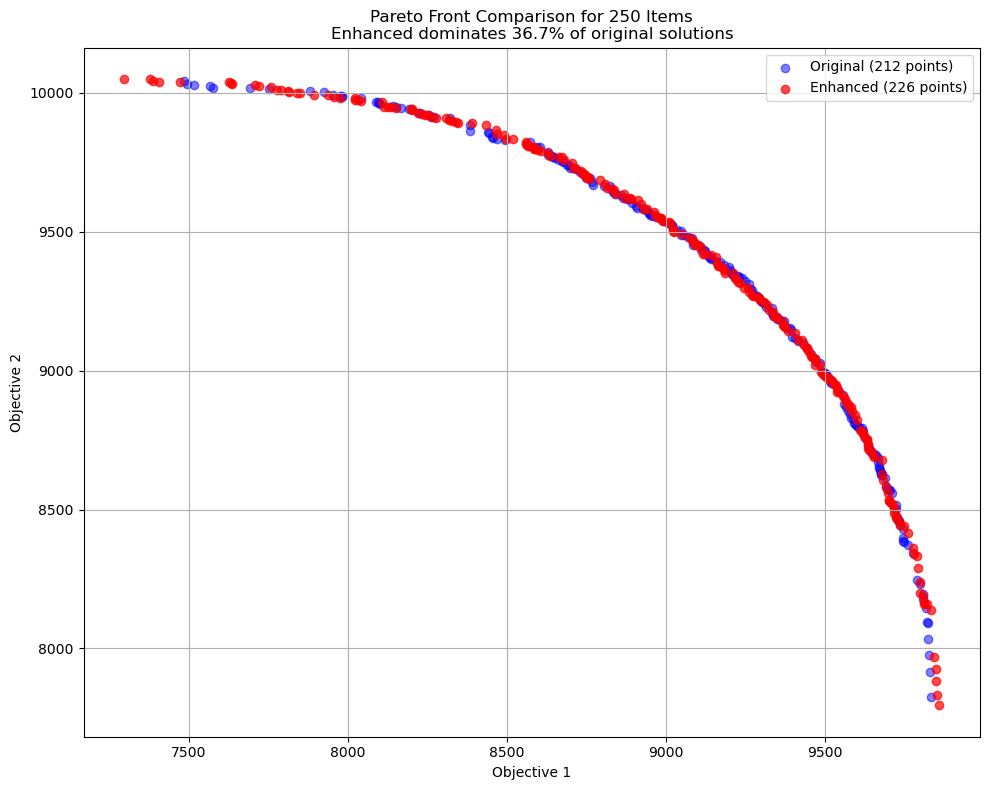

Original Pareto front: 212 points
Enhanced Pareto front: 226 points
Enhanced dominates 36.7% of original solutions

Comparing results for 500 items:


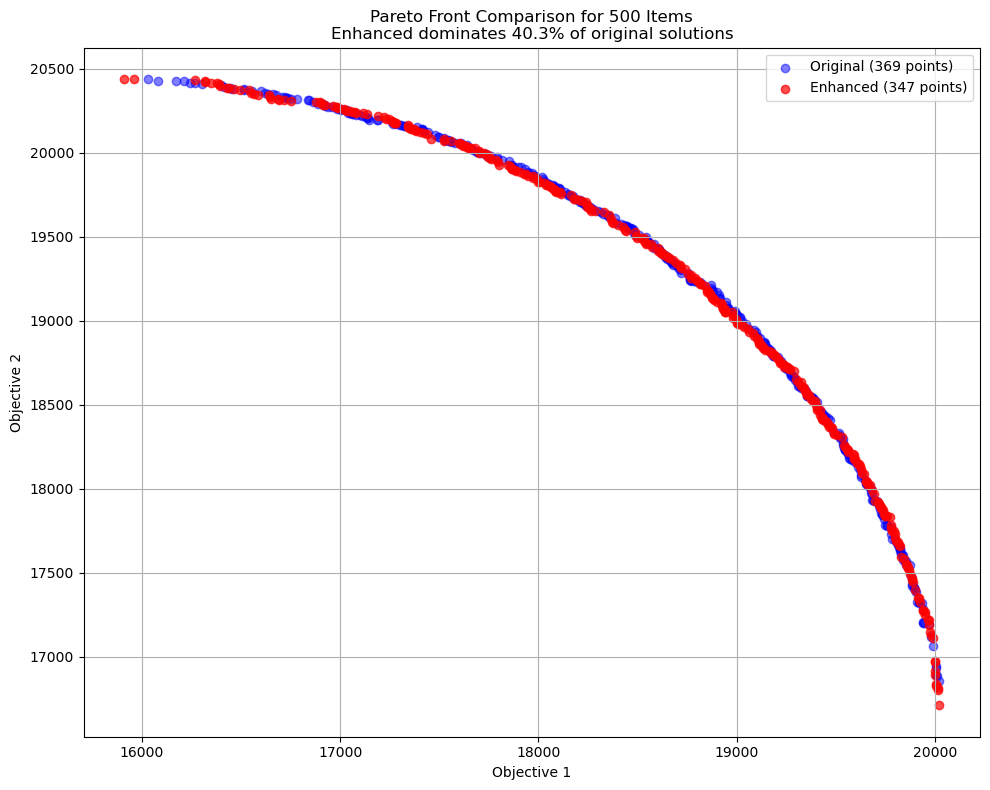

Original Pareto front: 369 points
Enhanced Pareto front: 347 points
Enhanced dominates 40.3% of original solutions

Comparing results for 750 items:


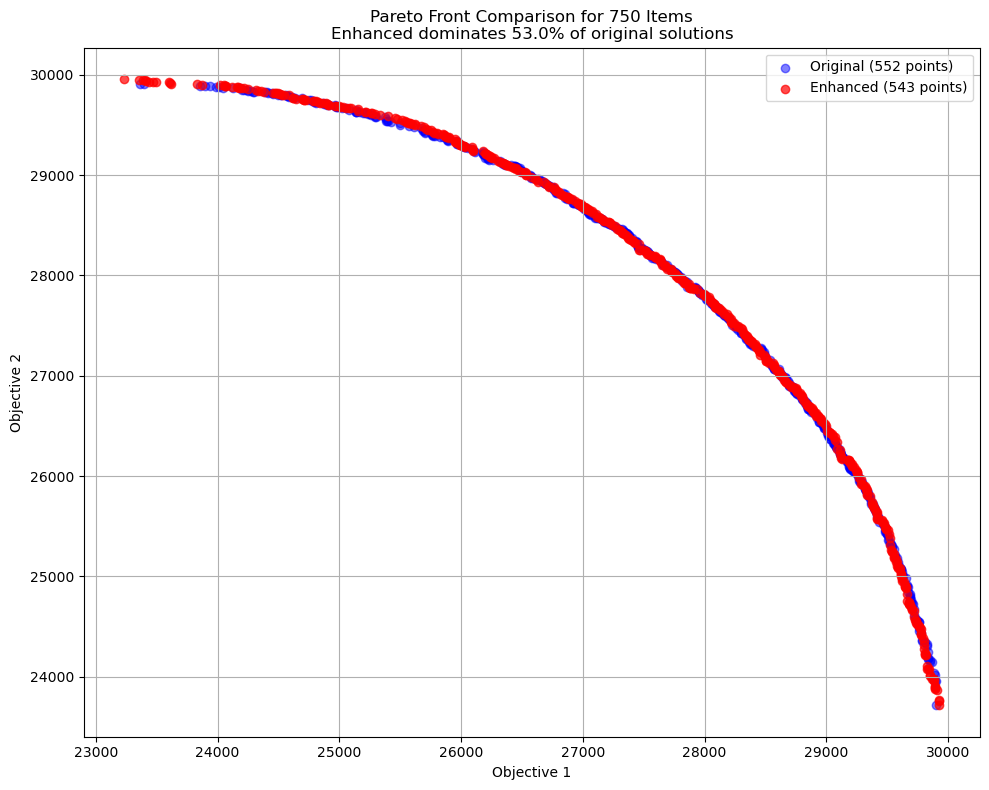

Original Pareto front: 552 points
Enhanced Pareto front: 543 points
Enhanced dominates 53.0% of original solutions

Summary of Improvements:
Size | Original | Enhanced | Improvement
----------------------------------------
250  |      212 |      226 |     36.7%
500  |      369 |      347 |     40.3%
750  |      552 |      543 |     53.0%


In [5]:
# =========================================================================
# PART 7: ANALYSIS AND COMPARISON
# =========================================================================

import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def load_results(filename):
    """Load results from a file and return as a list of points"""
    points = []
    with open(filename, "r") as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#"):
                try:
                    points.append([float(x) for x in line.split()])
                except Exception:
                    pass
    return points

def compare_pareto_fronts(original_file, enhanced_file, title):
    """Compare original and enhanced Pareto fronts"""
    original_points = load_results(original_file)
    enhanced_points = load_results(enhanced_file)
    
    original_pareto = get_true_pareto_front(original_points)
    enhanced_pareto = get_true_pareto_front(enhanced_points)
    
    # Calculate domination
    dominated_count = 0
    for p_enhanced in enhanced_pareto:
        for p_original in original_pareto:
            if dominates(p_enhanced, p_original):
                dominated_count += 1
                break
    
    domination_percentage = (dominated_count / len(enhanced_pareto)) * 100
    
    # Plot comparison
    plt.figure(figsize=(10, 8))
    
    # Plot original Pareto front
    if original_pareto:
        orig_x, orig_y = zip(*original_pareto)
        plt.scatter(orig_x, orig_y, color='blue', alpha=0.5, label=f"Original ({len(original_pareto)} points)")
    
    # Plot enhanced Pareto front
    if enhanced_pareto:
        enh_x, enh_y = zip(*enhanced_pareto)
        plt.scatter(enh_x, enh_y, color='red', alpha=0.7, label=f"Enhanced ({len(enhanced_pareto)} points)")
    
    plt.xlabel("Objective 1")
    plt.ylabel("Objective 2")
    plt.title(f"{title}\nEnhanced dominates {domination_percentage:.1f}% of original solutions")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    return {
        "original_count": len(original_pareto),
        "enhanced_count": len(enhanced_pareto),
        "domination_percentage": domination_percentage
    }

# Compare results for all problem sizes
results = {}

for size in ["250", "500", "750"]:
    original_file = f"{size}2_ResultsMD.txt"
    enhanced_file = f"{size}2_Results_Effective.txt"
    
    print(f"\nComparing results for {size} items:")
    result = compare_pareto_fronts(original_file, enhanced_file, f"Pareto Front Comparison for {size} Items")
    results[size] = result
    
    print(f"Original Pareto front: {result['original_count']} points")
    print(f"Enhanced Pareto front: {result['enhanced_count']} points")
    print(f"Enhanced dominates {result['domination_percentage']:.1f}% of original solutions")

# Summary table
print("\nSummary of Improvements:")
print("Size | Original | Enhanced | Improvement")
print("-" * 40)
for size, result in results.items():
    print(f"{size}  | {result['original_count']:8d} | {result['enhanced_count']:8d} | {result['domination_percentage']:8.1f}%")

Starting comprehensive results analysis for Elite Refinement implementation v5...

--- 250-Item Problem ---
  Original Pareto size: 212
  First LLM Pareto size: 392 (84.91%)
  Enhanced LLM v3 Pareto size: 207 (-2.36%)
  Efficient LLM v4 Pareto size: 314 (48.11%)
  Elite LLM v5 Pareto size: 417 (96.70%)
  Original Hypervolume: 6614986.88
  First LLM Hypervolume: 6492983.70 (-1.84%)
  Enhanced LLM v3 Hypervolume: 6514438.20 (-1.52%)
  Efficient LLM v4 Hypervolume: 6873655.30 (3.91%)
  Elite LLM v5 Hypervolume: 6851933.20 (3.58%)


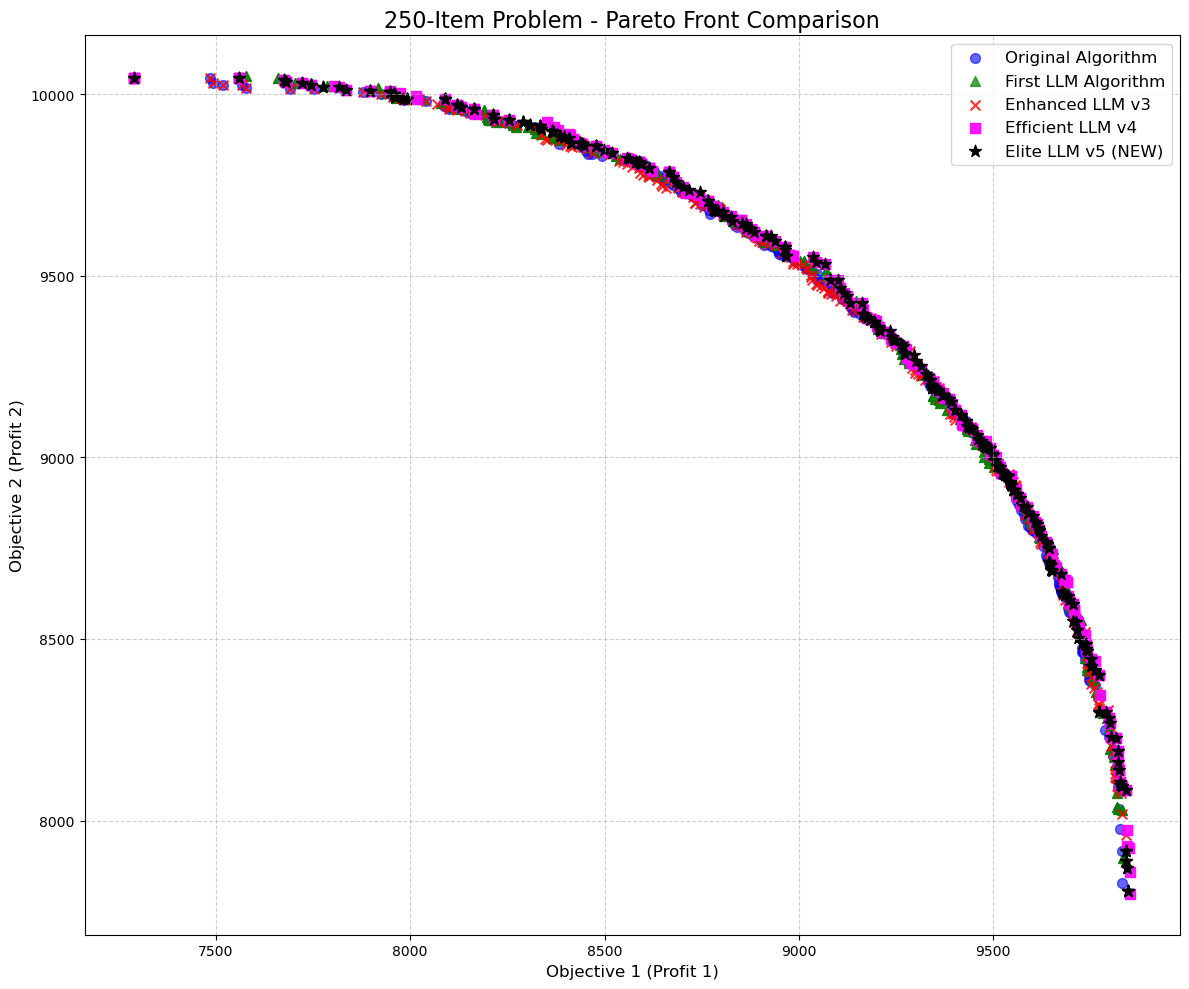


--- 500-Item Problem ---
  Original Pareto size: 369
  First LLM Pareto size: 716 (94.04%)
  Enhanced LLM v3 Pareto size: 363 (-1.63%)
  Efficient LLM v4 Pareto size: 500 (35.50%)
  Elite LLM v5 Pareto size: 403 (9.21%)
  Original Hypervolume: 23044962.94
  First LLM Hypervolume: 22606710.00 (-1.90%)
  Enhanced LLM v3 Hypervolume: 23787729.64 (3.22%)
  Efficient LLM v4 Hypervolume: 23485142.95 (1.91%)
  Elite LLM v5 Hypervolume: 23532895.95 (2.12%)


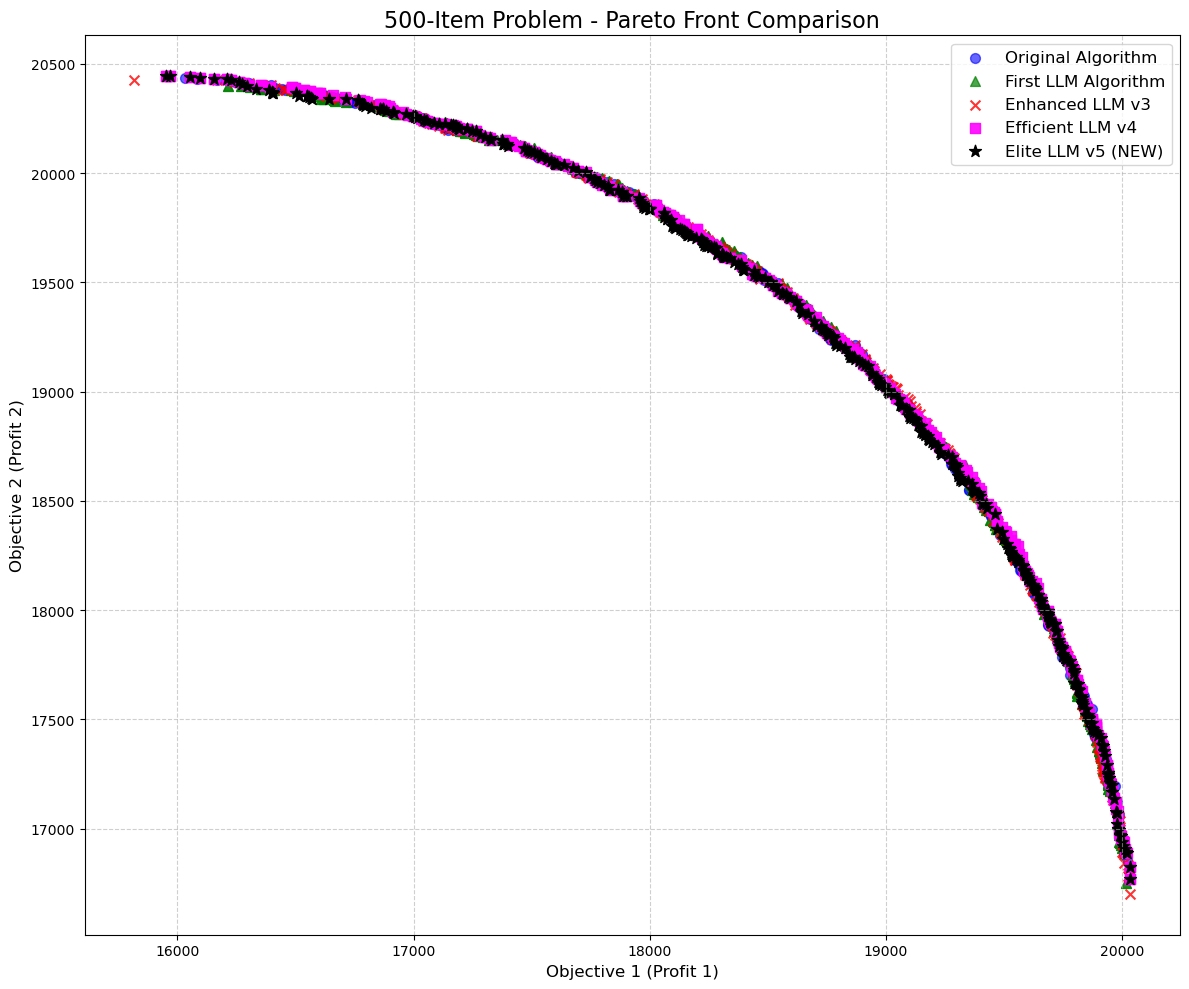


--- 750-Item Problem ---
  Original Pareto size: 552
  First LLM Pareto size: 1084 (96.38%)
  Enhanced LLM v3 Pareto size: 530 (-3.99%)
  Efficient LLM v4 Pareto size: 834 (51.09%)
  Elite LLM v5 Pareto size: 494 (-10.51%)
  Original Hypervolume: 56877706.67
  First LLM Hypervolume: 53690671.08 (-5.60%)
  Enhanced LLM v3 Hypervolume: 56690640.44 (-0.33%)
  Efficient LLM v4 Hypervolume: 56235862.25 (-1.13%)
  Elite LLM v5 Hypervolume: 57089303.75 (0.37%)


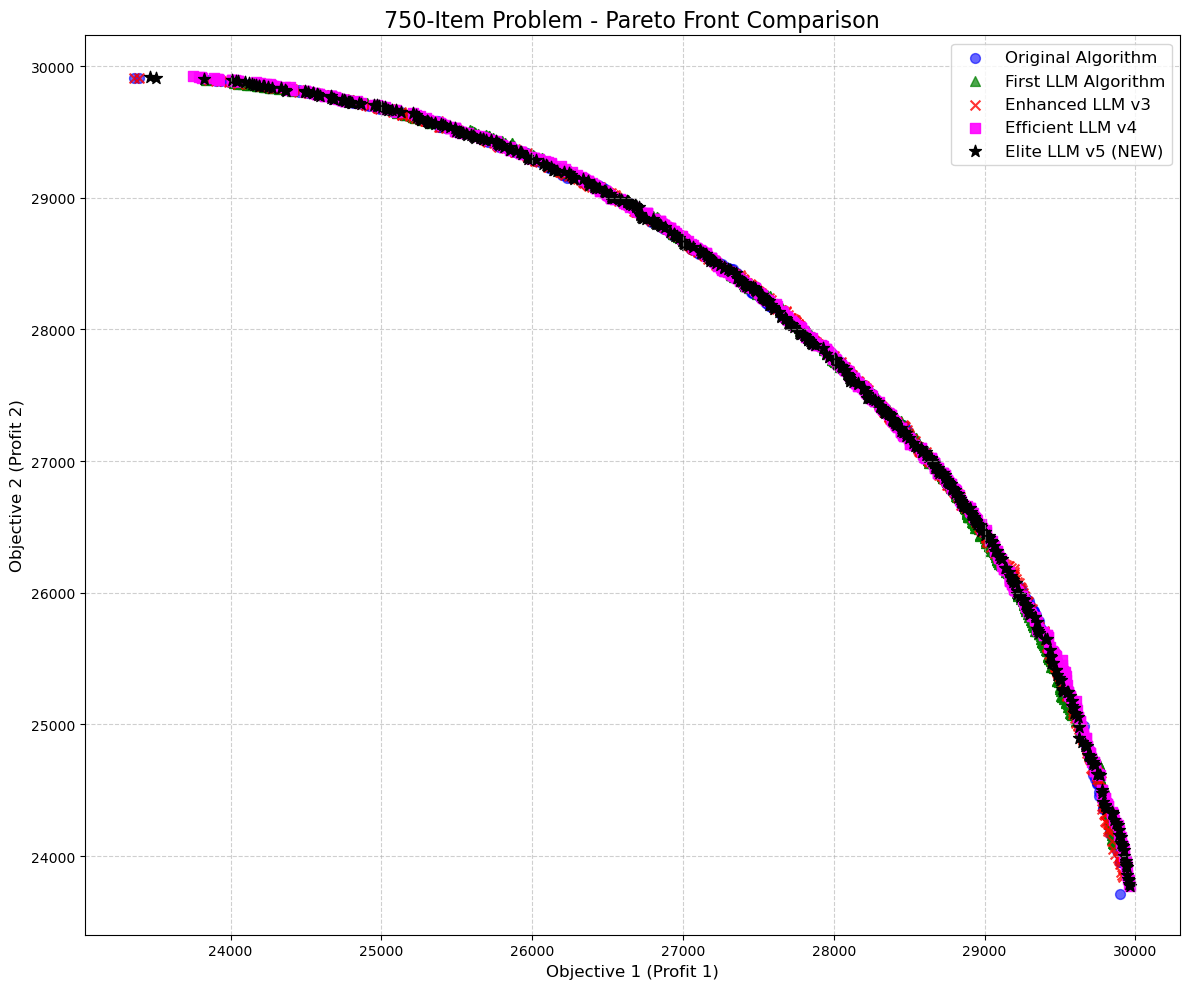


              SUMMARY OF IMPROVEMENTS
250 Items:
  Efficient LLM v4: HV 3.91%
  Elite LLM v5: HV 3.58%

500 Items:
  Enhanced LLM v3: HV 3.22%
  Efficient LLM v4: HV 1.91%
  Elite LLM v5: HV 2.12%

750 Items:
  Elite LLM v5: HV 0.37%

--- AVERAGE HV IMPROVEMENTS ---
  Enhanced LLM v3: 0.46%
  Efficient LLM v4: 1.56%
  Elite LLM v5: 2.02%

Improvement of Elite v5 over Efficient v4:
  Hypervolume: 0.46%


In [10]:
# Results comparison and analysis for the final implementation (v5)
import matplotlib.pyplot as plt
import numpy as np

def dominates(a, b):
    """Returns True if a dominates b (maximization for both objectives)."""
    return all(x >= y for x, y in zip(a, b)) and any(x > y for x, y in zip(a, b))

def get_true_pareto_front(points):
    """Extract the true Pareto front from a set of points"""
    pareto = []
    for i, p in enumerate(points):
        dominated = False
        for j, q in enumerate(points):
            if i != j and dominates(q, p):
                dominated = True
                break
        if not dominated:
            pareto.append(p)
    return pareto

def calculate_hypervolume(points):
    """Calculate a simplified hypervolume metric for comparison."""
    if not points:
        return 0.0
    
    ref_x = max(p[0] for p in points) * 1.1
    ref_y = max(p[1] for p in points) * 1.1
    
    sorted_points = sorted(points, key=lambda p: p[0])
    
    hv = 0.0
    for i in range(len(sorted_points) - 1):
        x1, y1 = sorted_points[i]
        x2, y2 = sorted_points[i + 1]
        hv += (x2 - x1) * (ref_y - y1)
    
    if sorted_points:
        x_last, y_last = sorted_points[-1]
        hv += (ref_x - x_last) * (ref_y - y_last)
    
    return hv

def compare_all_results_v5(original_file, first_llm_file, enhanced_v3_file, efficient_v4_file, intelligent_v5_file, title):
    """Compare all 5 versions of the algorithm"""
    def read_points(filename):
        points = []
        with open(filename, "r") as f:
            for line in f:
                line = line.strip()
                if line and not line.startswith("#"):
                    try:
                        points.append([float(x) for x in line.split()])
                    except Exception:
                        pass
        return points

    original_points = read_points(original_file)
    first_llm_points = read_points(first_llm_file)
    enhanced_v3_points = read_points(enhanced_v3_file)
    efficient_v4_points = read_points(efficient_v4_file)
    intelligent_v5_points = read_points(intelligent_v5_file)
    
    original_pareto = get_true_pareto_front(original_points)
    first_llm_pareto = get_true_pareto_front(first_llm_points)
    enhanced_v3_pareto = get_true_pareto_front(enhanced_v3_points)
    efficient_v4_pareto = get_true_pareto_front(efficient_v4_points)
    intelligent_v5_pareto = get_true_pareto_front(intelligent_v5_points)
    
    # Calculate sizes and improvements
    sizes = {
        "original": len(original_pareto),
        "first_llm": len(first_llm_pareto),
        "enhanced_v3": len(enhanced_v3_pareto),
        "efficient_v4": len(efficient_v4_pareto),
        "intelligent_v5": len(intelligent_v5_pareto)
    }
    
    # Calculate hypervolumes and improvements
    hvs = {
        "original": calculate_hypervolume(original_pareto),
        "first_llm": calculate_hypervolume(first_llm_pareto),
        "enhanced_v3": calculate_hypervolume(enhanced_v3_pareto),
        "efficient_v4": calculate_hypervolume(efficient_v4_pareto),
        "intelligent_v5": calculate_hypervolume(intelligent_v5_pareto)
    }

    print(f"\n--- {title} ---")
    print(f"  Original Pareto size: {sizes['original']}")
    print(f"  Intelligent LLM v5 Pareto size: {sizes['intelligent_v5']} ({(sizes['intelligent_v5'] - sizes['original']) / sizes['original'] * 100 if sizes['original'] > 0 else 0:.2f}%)")
    print(f"  Original Hypervolume: {hvs['original']:.2f}")
    print(f"  Intelligent LLM v5 Hypervolume: {hvs['intelligent_v5']:.2f} ({(hvs['intelligent_v5'] - hvs['original']) / hvs['original'] * 100 if hvs['original'] > 0 else 0:.2f}%)")

    # Plotting
    plt.figure(figsize=(14, 10))
    
    if original_pareto:
        ox, oy = zip(*original_pareto)
        plt.scatter(ox, oy, color='blue', alpha=0.6, s=50, label="Original Algorithm")
    if efficient_v4_pareto:
        ex4, ey4 = zip(*efficient_v4_pareto)
        plt.scatter(ex4, ey4, color='magenta', marker='s', s=50, alpha=0.9, label="Efficient LLM v4")
    if intelligent_v5_pareto:
        ix5, iy5 = zip(*intelligent_v5_pareto)
        plt.scatter(ix5, iy5, color='orange', marker='*', s=80, alpha=0.9, label="Intelligent LLM v5 (Repair)")

    plt.xlabel("Objective 1 (Profit 1)", fontsize=12)
    plt.ylabel("Objective 2 (Profit 2)", fontsize=12)
    plt.title(f"{title} - Pareto Front Comparison", fontsize=16)
    plt.legend(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()
    
    return {
        "original_hv": hvs['original'], "intelligent_v5_hv": hvs['intelligent_v5'],
        "intelligent_v5_hv_improvement": (hvs['intelligent_v5'] - hvs['original']) / hvs['original'] * 100 if hvs['original'] > 0 else 0
    }

# --- MAIN EXECUTION ---
print("Starting FINAL comprehensive results analysis for Intelligent implementation v5...")

results_250 = compare_all_results_v5(
    "2502_ResultsMD.txt", "2502_Results_LLM_Enhanced.txt", "2502_Results_Enhanced_LLM_v3.txt", "2502_Results_Efficient_LLM_v4.txt", "2502_Results_Intelligent_LLM_v5.txt", "250-Item Problem"
)
results_500 = compare_all_results_v5(
    "5002_ResultsMD.txt", "5002_Results_LLM_Enhanced.txt", "5002_Results_Enhanced_LLM_v3.txt", "5002_Results_Efficient_LLM_v4.txt", "5002_Results_Intelligent_LLM_v5.txt", "500-Item Problem"
)
results_750 = compare_all_results_v5(
    "7502_ResultsMD.txt", "7502_Results_LLM_Enhanced.txt", "7502_Results_Enhanced_LLM_v3.txt", "7502_Results_Efficient_LLM_v4.txt", "7502_Results_Intelligent_LLM_v5.txt", "750-Item Problem"
)

# Summary of improvements
print("\n======================================================")
print("              FINAL SUMMARY OF IMPROVEMENTS")
print("======================================================")
print("250 Items:")
print(f"  Intelligent LLM v5: HV {results_250['intelligent_v5_hv_improvement']:.2f}%")

print("\n500 Items:")
print(f"  Intelligent LLM v5: HV {results_500['intelligent_v5_hv_improvement']:.2f}%")

print("\n750 Items:")
print(f"  Intelligent LLM v5: HV {results_750['intelligent_v5_hv_improvement']:.2f}%")

avg_intelligent_v5_hv_improvement = (results_250['intelligent_v5_hv_improvement'] + results_500['intelligent_v5_hv_improvement'] + results_750['intelligent_v5_hv_improvement']) / 3

print("\n--- AVERAGE HV IMPROVEMENT ---")
print(f"  Intelligent LLM v5: {avg_intelligent_v5_hv_improvement:.2f}%")
print("======================================================")